In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
import pyoti.sparse as oti
from jetgp.wdegp.wdegp import wdegp
import jetgp.utils as utils

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_order = 2
n_bases = 2
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
n_restarts = 15
swarm_size = 200
np.random.seed(42)

In [3]:
def six_hump_camelback(X, alg=np):
    """
    Six-hump camelback function, a 2D benchmark function with multiple local minima.
    """
    x1 = X[:, 0]
    x2 = X[:, 1]
    return (
        (4 - 2.1 * x1**2 + (x1**4) / 3.0) * x1**2
        + x1 * x2
        + (-4 + 4 * x2**2) * x2**2
    )

In [4]:
def create_training_grid(lb=-1.0, ub=1.0, num_points=4):
    """
    Create a 2D training grid with derivatives at interior points.

    No reordering needed - indices can be non-contiguous!
    """
    # Uniform 2D grid
    x_vals = np.linspace(lb, ub, num_points)
    y_vals = np.linspace(lb, ub, num_points)
    X = np.array(list(itertools.product(x_vals, y_vals)))

    # Interior points where we want derivatives (no reordering needed!)
    # In a 4x4 grid, interior points are [5, 6, 9, 10]
    derivative_indices = [5, 6, 9, 10]

    # Build submodel_indices structure:
    # submodel_indices[submodel][deriv_idx] = [list of point indices]
    # We have 4 derivatives total (2 dims × 2 orders), so 4 entries
    num_derivatives = n_bases * n_order  # 2 × 2 = 4
    submodel_indices = [
        [derivative_indices for _ in range(num_derivatives)]
    ]

    # Build derivative_specs structure:
    # derivative_specs[submodel][deriv_idx] = derivative spec
    # For 2D with all derivatives (4 total):
    derivative_specs = [
     [
         [[[1, 1]], [[2, 1]]],  # 1st order derivatives
         [[[1, 2]], [[2, 2]]]   # 2nd order derivatives
     ]
     ]

    return X, submodel_indices, derivative_specs, derivative_indices

X_train, submodel_indices, derivative_specs, derivative_indices = create_training_grid()

print(f"Total training points: {len(X_train)}")
print(f"Derivative indices (non-contiguous): {derivative_indices}")
print(f"\nsubmodel_indices: {len(submodel_indices[0])} entries (one per derivative)")
print(f"\nderivative_specs:")
deriv_names = ["df/dx1", "df/dx2", "d2f/dx1^2", "d2f/dx2^2"]
for i, spec in enumerate(derivative_specs[0]):
    print(f"  [{i}] {deriv_names[i]}: {spec}")

Total training points: 16
Derivative indices (non-contiguous): [5, 6, 9, 10]

submodel_indices: 4 entries (one per derivative)

derivative_specs:
  [0] df/dx1: [[[1, 1]], [[2, 1]]]
  [1] df/dx2: [[[1, 2]], [[2, 2]]]


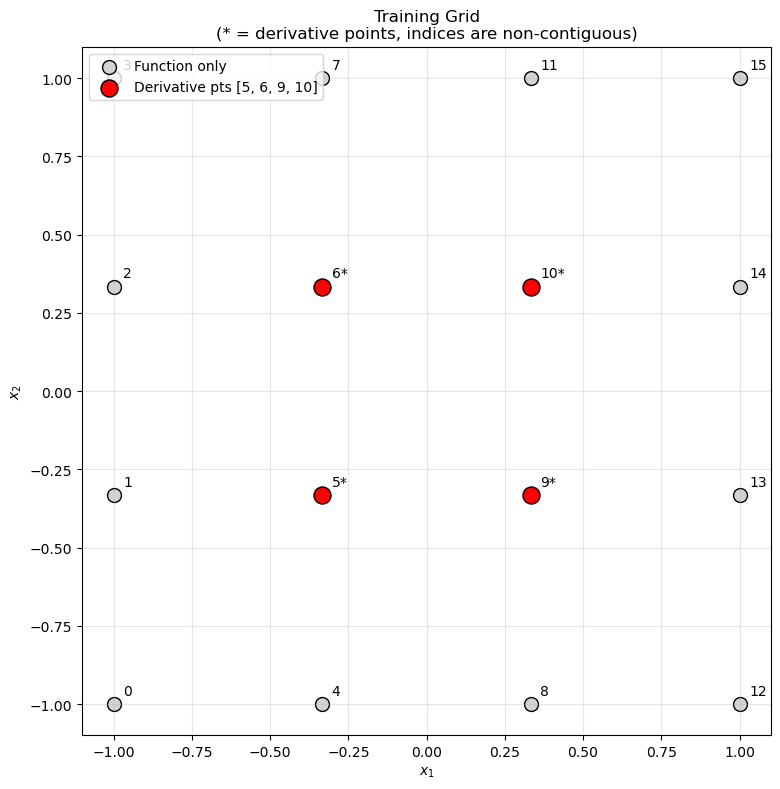

In [5]:
def visualize_grid(X_train, derivative_indices, lb=-1.0, ub=1.0):
    """Visualize the training grid with derivative points highlighted."""
    fig, ax = plt.subplots(figsize=(8, 8))

    # All points
    ax.scatter(X_train[:, 0], X_train[:, 1],
               c='lightgray', s=100, edgecolor='k', label='Function only')

    # Derivative points (non-contiguous indices!)
    ax.scatter(X_train[derivative_indices, 0], X_train[derivative_indices, 1],
               c='red', s=150, edgecolor='k', label=f'Derivative pts {derivative_indices}')

    # Label all points with their index
    for i, p in enumerate(X_train):
        label = f"{i}*" if i in derivative_indices else str(i)
        ax.text(p[0] + 0.03, p[1] + 0.03, label, fontsize=10)

    ax.set_title("Training Grid\n(* = derivative points, indices are non-contiguous)")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

visualize_grid(X_train, derivative_indices)

In [6]:
def prepare_training_data(X_train, submodel_indices, derivative_specs, func, n_order=2):
    """
    Prepare function values and derivatives for WDEGP.

    Returns:
        submodel_data: List of [func_values, deriv_0, deriv_1, ...]
        where each deriv corresponds to one entry in derivative_specs
    """
    # Function values at ALL training points
    y_function_values = func(X_train, alg=np).reshape(-1, 1)

    submodel_data = []

    for k, (sm_indices, sm_deriv_specs) in enumerate(zip(submodel_indices, derivative_specs)):
        # Get the point indices for derivatives (same for all derivs in this example)
        point_indices = sm_indices[0]

        # Create OTI array for automatic differentiation
        X_sub = oti.array(X_train[point_indices])

        # Add OTI dual components for each dimension
        for dim in range(n_bases):
            for j in range(X_sub.shape[0]):
                X_sub[j, dim] += oti.e(dim + 1, order=n_order)

        # Evaluate function with OTI to get derivatives automatically
        y_with_derivs = oti.array([
            func(x, alg=oti)[0] for x in X_sub
        ])

        # Build submodel data: [func_values, deriv_0, deriv_1, ...]
        # Each derivative corresponds to one entry in derivative_specs
        current_data = [y_function_values]

        # Extract derivatives for each order
        for order_idx, order_specs in enumerate(sm_deriv_specs):
             for deriv_spec in order_specs:
                 deriv_values = y_with_derivs.get_deriv(deriv_spec).reshape(-1, 1)
                 current_data.append(deriv_values)

        submodel_data.append(current_data)

        print(f"Submodel {k} data structure:")
        print(f"  Function values: shape {current_data[0].shape} (all {len(X_train)} points)")
        deriv_names = ["df/dx1", "df/dx2", "d2f/dx1^2", "d2f/dx2^2"]
        for idx, arr in enumerate(current_data[1:]):
            print(f"  [{idx}] {deriv_names[idx]}: shape {arr.shape} ({len(point_indices)} points)")

    return submodel_data

submodel_data = prepare_training_data(
    X_train, submodel_indices, derivative_specs, six_hump_camelback, n_order
)
print(f"\nTotal submodels: {len(submodel_data)}")
print(f"Arrays per submodel: {len(submodel_data[0])}")

Submodel 0 data structure:
  Function values: shape (16, 1) (all 16 points)
  [0] df/dx1: shape (4, 1) (4 points)
  [1] df/dx2: shape (4, 1) (4 points)
  [2] d2f/dx1^2: shape (4, 1) (4 points)
  [3] d2f/dx2^2: shape (4, 1) (4 points)

Total submodels: 1
Arrays per submodel: 5


In [7]:
print("Building WDEGP model...")
print(f"  Training points: {len(X_train)}")
print(f"  Derivative points: {len(derivative_indices)} (at indices {derivative_indices})")
print(f"  Derivatives per point: {n_bases * n_order} (2 dims × 2 orders)")

gp_model = wdegp(
    X_train,
    submodel_data,
    n_order,
    n_bases,
    derivative_specs,
    derivative_locations = submodel_indices,
    normalize=normalize_data,
    kernel=kernel,
    kernel_type=kernel_type,
)

print("\nOptimizing hyperparameters...")
params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size=100,
    n_generations=15,
    local_opt_every=None,
    debug=True
)

print("\nOptimized parameters:")
print(params)

Building WDEGP model...
  Training points: 16
  Derivative points: 4 (at indices [5, 6, 9, 10])
  Derivatives per point: 4 (2 dims × 2 orders)

Optimizing hyperparameters...


Gen 1: best f=47.91385918475584
Gen 2: best f=18.045345256799862
Gen 3: best f=18.045345256799862
Gen 4: best f=18.045345256799862
Gen 5: best f=15.348355135768827
Gen 6: best f=15.348355135768827
Gen 7: best f=15.348355135768827


Gen 8: best f=13.233077630609856
Gen 9: best f=11.936236154792113
Gen 10: best f=11.936236154792113
Gen 11: best f=11.516952793850749
Gen 12: best f=11.516952793850749
Gen 13: best f=11.516952793850749
Gen 14: best f=11.516952793850749


Gen 15: best f=11.516952793850749

Optimized parameters:
[ -0.26883153  -0.09019859   0.94748321 -14.09571385]


In [8]:
def evaluate_gp(gp_model, func, params, lb=-1.0, ub=1.0, N=50):
    """Evaluate GP on a dense test grid."""
    x_lin = np.linspace(lb, ub, N)
    y_lin = np.linspace(lb, ub, N)
    X1, X2 = np.meshgrid(x_lin, y_lin)
    X_test = np.column_stack([X1.ravel(), X2.ravel()])

    y_pred = gp_model.predict(X_test, params, calc_cov=False)
    y_true = func(X_test, alg=np)

    # Error metrics
    rmse = np.sqrt(np.mean((y_true - y_pred.flatten())**2))
    nrmse = rmse / (y_true.max() - y_true.min())
    mae = np.mean(np.abs(y_true - y_pred.flatten()))

    return X1, X2, y_true.reshape(N, N), y_pred.reshape(N, N), nrmse, rmse, mae

X1, X2, y_true_grid, y_pred_grid, nrmse, rmse, mae = evaluate_gp(
    gp_model, six_hump_camelback, params
)
print(f"NRMSE: {nrmse:.6f}")
print(f"RMSE:  {rmse:.6f}")
print(f"MAE:   {mae:.6f}")

NRMSE: 0.012538
RMSE:  0.053467
MAE:   0.034333


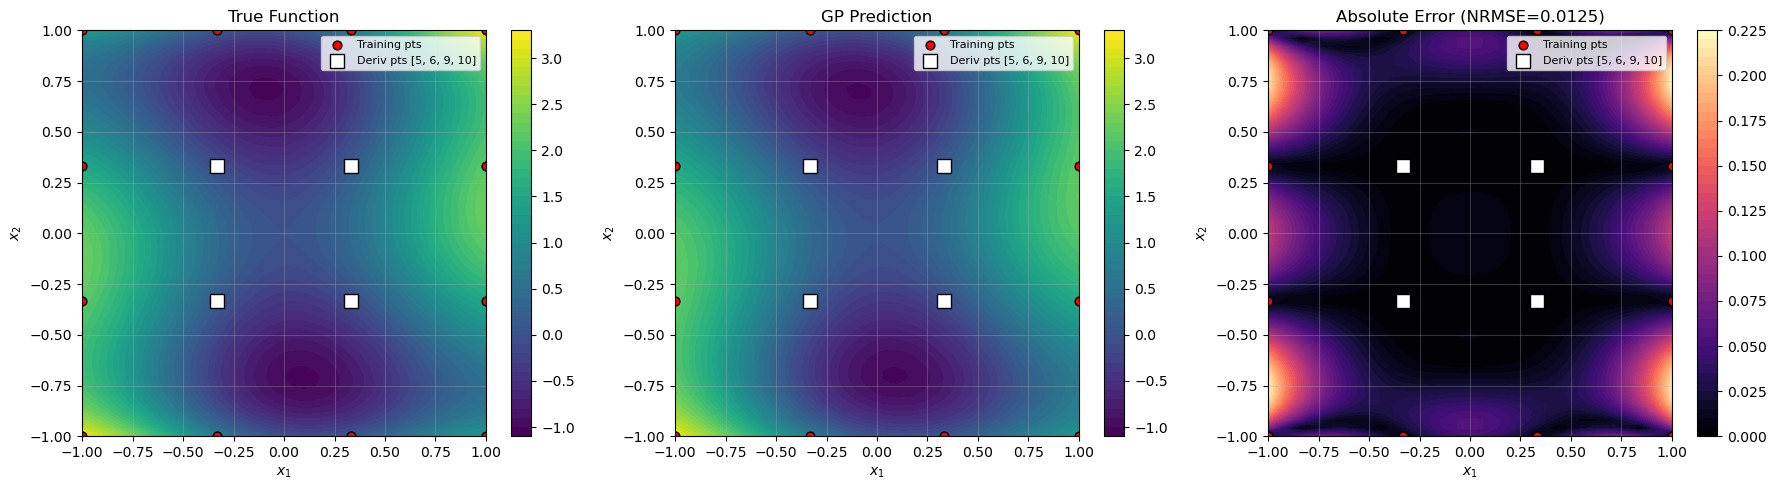

In [9]:
def visualize_results(X1, X2, y_true, y_pred, X_train, derivative_indices, nrmse):
    """Create contour plots of true function, prediction, and error."""
    abs_err = np.abs(y_true - y_pred)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    titles = ["True Function", "GP Prediction", f"Absolute Error (NRMSE={nrmse:.4f})"]
    data = [y_true, y_pred, abs_err]
    cmaps = ["viridis", "viridis", "magma"]

    for ax, Z, title, cmap in zip(axes, data, titles, cmaps):
        c = ax.contourf(X1, X2, Z, levels=50, cmap=cmap)
        fig.colorbar(c, ax=ax)

        # All training points
        ax.scatter(X_train[:, 0], X_train[:, 1],
                   c='red', edgecolor='k', s=40, label='Training pts')

        # Derivative points (highlighted)
        ax.scatter(X_train[derivative_indices, 0], X_train[derivative_indices, 1],
                   c='white', edgecolor='k', s=100, marker='s',
                   label=f'Deriv pts {derivative_indices}')

        ax.set_title(title)
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

visualize_results(X1, X2, y_true_grid, y_pred_grid, X_train, derivative_indices, nrmse)

In [10]:
print("=" * 70)
print("Derivative verification using return_deriv=True")
print("=" * 70)

# Get predictions with derivatives at the derivative training points
X_deriv_pts = X_train[derivative_indices]
y_pred_with_derivs = gp_model.predict(X_deriv_pts, params, calc_cov=False, return_deriv=True)

print(f"\nPrediction shape: {y_pred_with_derivs.shape}")
print("  Row 0: function values")
print("  Row 1: df/dx1 (1st order, dim 1)")
print("  Row 2: df/dx2 (1st order, dim 2)")
print("  Row 3: d²f/dx1² (2nd order, dim 1)")
print("  Row 4: d²f/dx2² (2nd order, dim 2)")

# Compare with training data
print("\n1st order derivatives (df/dx1):")
pred_d1_x1 = y_pred_with_derivs[1, :]
true_d1_x1 = submodel_data[0][1].flatten()  # 1st deriv array
for i, idx in enumerate(derivative_indices):
    rel_err = abs(pred_d1_x1[i] - true_d1_x1[i]) / abs(true_d1_x1[i]) if true_d1_x1[i] != 0 else 0
    print(f"  Point {idx}: Pred={pred_d1_x1[i]:.6f}, True={true_d1_x1[i]:.6f}, RelErr={rel_err:.2e}")

print("\n1st order derivatives (df/dx2):")
pred_d1_x2 = y_pred_with_derivs[2, :]
true_d1_x2 = submodel_data[0][2].flatten()
for i, idx in enumerate(derivative_indices):
    rel_err = abs(pred_d1_x2[i] - true_d1_x2[i]) / abs(true_d1_x2[i]) if true_d1_x2[i] != 0 else 0
    print(f"  Point {idx}: Pred={pred_d1_x2[i]:.6f}, True={true_d1_x2[i]:.6f}, RelErr={rel_err:.2e}")

Derivative verification using return_deriv=True
Making predictions for all derivatives that are common among submodels

Prediction shape: (5, 4)
  Row 0: function values
  Row 1: df/dx1 (1st order, dim 1)
  Row 2: df/dx2 (1st order, dim 2)
  Row 3: d²f/dx1² (2nd order, dim 1)
  Row 4: d²f/dx2² (2nd order, dim 2)

1st order derivatives (df/dx1):
  Point 5: Pred=5.323457, True=-2.697119, RelErr=2.97e+00
  Point 6: Pred=5.323457, True=-2.030453, RelErr=3.62e+00
  Point 9: Pred=5.323457, True=2.030453, RelErr=1.62e+00
  Point 10: Pred=5.323457, True=2.697119, RelErr=9.74e-01

1st order derivatives (df/dx2):
  Point 5: Pred=-2.697119, True=1.740741, RelErr=2.55e+00
  Point 6: Pred=-2.030453, True=-2.407407, RelErr=1.57e-01
  Point 9: Pred=2.030453, True=2.407407, RelErr=1.57e-01
  Point 10: Pred=2.697119, True=-1.740741, RelErr=2.55e+00
